# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [264]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [265]:
# cargar archivos
plans =  pd.read_csv('/datasets/plans.csv')
users =  pd.read_csv('/datasets/users_latam.csv')
usage =  pd.read_csv('/datasets/usage.csv')

In [266]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [267]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [268]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [269]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [270]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [271]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [272]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [273]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [274]:

# cantidad de nulos para usage
print(usage.isna().sum())# Cantidad de valores nulos)
print(usage.isna().mean()) # Proporción de valores nulos)


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: despues de aplicar el metodo para detectar los Nulos se puede observar en el Dataset  de **user** que:
**City** tiene un 11,7% de valores nulos por lo que entraria en el Hint en los que generalmente se investigan para imputarlo o dejarlos como nulos.

**churn_date** tiene un 88,35% de valores nulos, segun el hint estos valores normalmente se ignoran o se eliminan, en este caso nos representa la fecha de cancelación, por lo que solamente se registra la fecha donde se dio de baja el servicio por lo que en este caso los dejaria como nulos ya que considero que es una informacion valioso.

Por otro lado en el Dataset **Usage** verifique que:
**date** tiene el 0,125 de nulos por lo que este caso suele ser simple de imputacion o dejarlos directamente como nulos.
**duration** tiene un 55,19% de valores nulos lo cual no encaja en los rangos de hint, este sucede por son llamdas las cuales no tienen longitud de texto, asi mismo nos paso con *length* tiene un 44,74% de valores nulos al igual que el caso anterior no encaja en los rangos de hint, por lo que los textos no tienen duracion de minutos, por lo que estos dos paramentros no los eliminaria los dejare como nulos.


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [275]:
print(users[['user_id','age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000



**La columna user_id:** identificador secuencial limpio. La media es de (11,999.5) la cual coincide exactamente con la mitad entre min y max, por lo tanto puedo deducir que es una distribución uniforme. En cuanto a los cuartiles están igualmente espaciados. No hay anomalías.

**La columna age:** nos muestra que el valor mínimo  es −999 —por lo que puedo concluir que no es una edad real. Esto infla la desviación típica hasta 123, que de otro modo sería ~15–16 para edades reales.

In [276]:
print(usage[['id','user_id']].describe())# explorar columnas numéricas de usage

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000


- Las columna **id** es una clave primaria secuencial perfecta del 1 al 40,000 que me lo da el min y el max de los datos, sin huecos ni anomalías.
   
- Las columna **user_id** es una clave foránea que referencia a la tabla de usuarios que analice antes. El rango es de 10,000 a 13,999 es exactamente el mismo. Por lo que esto nos informa que estamos ante una tabla de transacciones vinculada a la tabla de usuarios.

In [277]:


# explorar columnas categóricas de users
columnas_user = ['city','plan']
print(users[columnas_user].describe())



          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna **city** Tiene 3.531 registros no nulos (count), por  lo que sugiere que hay 469 valores faltantes respecto a las 4.000 filas de plan, además se identificaron 7 ciudades unicas, donde la ciudad mas top es Bogotá considerada como la mas frecuente con 808 apariciciones.

- La columna **plan** Tiene 4.000 registros, todos completos es decir, sin valores nulos. se pudo identificar que hay dos tipos de planes, por lo que el mas común es el Basico con un total de 2.595 usuarios, es decir que casi el 65% de los clientes optaron por el plan mas economico.


In [278]:

# explorar columna categórica de usage
columnas_usage = ['type']
print(usage[columnas_usage].describe())# completa el código


         type
count   40000
unique      2
top      text
freq    22092




- La columna **type** Tiene 40.000 registros, todos completos, sin valores nulos.
Contiene 2 tipos únicos de valores uno es "text" y otro "call".

Ademas, se identifico que el tipo más frecuente es text, con 22.092 apariciones (freq), representando el 55,2% del total.
El tipo restante cuenta con 17.908 registros, es decir el 44,8% por lo que se pudo concluir que tiene una distribución bastante equilibrada entre ambas categorías, sin un desbalance preocupante.





---

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? por un lado tenemos las columnas numericas y por otro las categoricas, en cuanto a las numericas tenemos **La columna age** la cual nos muestra que el valor mínimo  es −999, por lo que puedo concluir que no es una edad real. Esto infla la desviación típica hasta 123, que de otro modo sería ~15–16 para edades reales.
por otro lago en las columnas categoricas esta **la columna city** es la de mayor riesgo dado que ya tiene 469 nulos reales, es probable que esconda valores inválidos. 
- ¿Qué acción tomarías? En el caso de la columna age los datos - 999 se deberian tratar como nulos, por otro lado en el caso de la columna City remplazaria con NaN, con esto despues decidiria si los mantenemos o los eliminariamos.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [279]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [280]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [281]:

# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64



En **reg_date**, Los años 2022, 2023 y 2024 son válidos con una distribución muy equilibrada de 1.300 registros cada uno, lo que indica un flujo de registros constante y consistente.
El año 2026 presenta 40 registros sospechosos, por lo que se puede deducir que son fechas futuras imposibles que representan el 1% del total y deben tratarse como datos inválidos.


In [282]:
print(usage['date'].dt.year.value_counts().sort_index())


2024.0    39950
Name: date, dtype: int64


En este print solo nos arrojo el año 2024 ya que nuestro analisis se enfoco especificamente en ese año,  donde nos mostro 39.950 registros, lo que coincide casi perfectamente con el total de 40.000 filas del DataFrame (la diferencia de 50 podría corresponder a valores nulos tras la conversión).



✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos).
las fechas que aparecieron fuera de rango en reg_date presenta una fecha fuera del rango, al ser un volumen pequeño (1%), la acción más segura es marcarlos como nulos a esos 40 registros para garantizar la integridad del análisis temporal, mientras que en las columna date usage solo nos arrojó el año 2024 ya que el análisis esta basado en este año en especifico.



---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [283]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [284]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [285]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())



2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [286]:

# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()).round(4))




type
call    0.0000
text    0.9993
Name: duration, dtype: float64


In [287]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()).round(4))

type
call    0.9993
text    0.0000
Name: length, dtype: float64


Los nulos en **duration y length** son MAR porque dependen del tipo de interacción, es decir que dependen de otra variable, en el caso de duration aplica solo a **call**,  en **text** es estructuralmente nulo, y en length aplica solo a **text**, en **call** es estructuralmente nulo.

Por lo tanto se dejan como nulos ya que imputarlos generaría datos falsos, y el análisis de cada columna se realizará por separado según el tipo

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [288]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes        = ("is_text",   "sum"),
    cant_llamadas        = ("is_call",   "sum"),
    cant_minutos_llamada = ("duration",  "sum")
).reset_index()



# Observar resultado
usage_agg.head(3)




,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [289]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text"  : "cant_mensajes",
    "is_call"  : "cant_llamadas",
    "duration" : "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [290]:



# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)




,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [291]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

user_profile[columnas_numericas].describe().round(2)

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,3999.00,3999.00,3999.00
mean,48.14,5.52,4.48,23.32
std,17.69,2.36,2.14,18.17
min,18.00,0.00,0.00,0.00
25%,33.00,4.00,3.00,11.12
50%,48.00,5.00,4.00,19.78
75%,63.00,7.00,6.00,31.42
max,79.00,17.00,15.00,155.69


In [292]:
# Distribución porcentual del tipo de plan
plan_dist = user_profile['plan'].value_counts(normalize=True).mul(100).round(2)
print(plan_dist)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.



**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

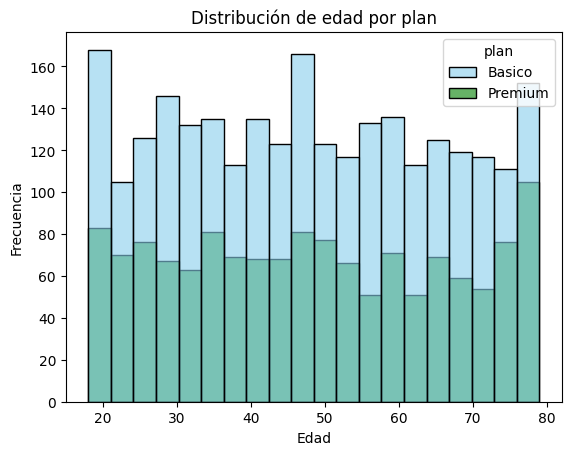

In [293]:
# Histograma para visualizar la edad (age)


sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',  
    palette=['skyblue', 'green'],
    bins=20,
    alpha=0.6)


plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de edad por plan')
plt.show()




**💡Insights: Distribución de edad por plan**

Distribución en terminos generales, en cuanto a la edad es relativamente uniforme entre los 20 y 80 años, sin una concentración clara en un grupo específico. Esto sugiere que el servicio tiene una audiencia amplia y diversa.
El Plan Básico, que se representa en color azul, los cuales representan la mayor parte de la frecuencia en casi todas las franjas de edad, dominando visualmente el histograma. Su presencia es consistente a lo largo de todos los rangos de edad, con picos notables alrededor de los 20 y 49 años (frecuencias ~165).

Por otro lado, en el Plan Premium se muestran una distribución también uniforme, pero con frecuencias más bajas y estables (~65–85 en la mayoría de franjas). No se observa ningún grupo de edad que adopte Premium de forma significativamente mayor que otro.

En conclusión podemos decir, que este histograma tiene una distribucion uniforme.

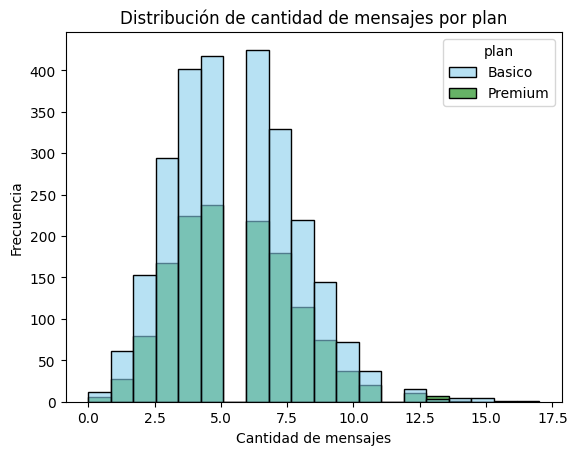

In [294]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',  
    palette=['skyblue', 'green'],
    bins=20,
    alpha=0.6)


plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.title('Distribución de cantidad de mensajes por plan')
plt.show()


**💡Insights: Distribucion de cantidad de mensajes por plan** 

La distribución presenta un sesgo positivo (hacia la derecha), con la mayoría de los usuarios concentrados entre 3 y 7 mensajes, y una cola que se extiende hasta los 17 mensajes. Pocos usuarios envían volúmenes muy altos.

En el plan básico, domina en todas las franjas, con su pico máximo alrededor de 5–6 mensajes con alrededor de 420 usuarios. La frecuencia cae bruscamente a partir de los 10 mensajes. Asi mismo, el plan premium sigue la misma forma que el plan Básico pero en menor volumen, con pico en 4–5 mensajes con alrededor de 240 usuarios. Proporcionalmente, los usuarios Premium también se concentran en el rango medio-bajo de mensajes.


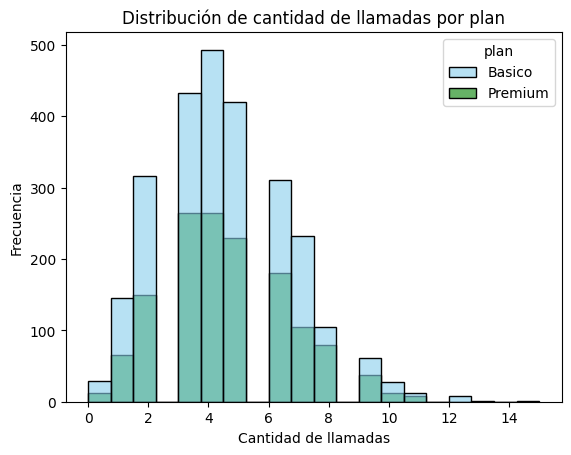

In [295]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',  
    palette=['skyblue', 'green'],
    bins=20,
    alpha=0.6)


plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribución de cantidad de llamadas por plan')
plt.show()


**💡Insights: Distribución de cantidad de llamadas por plan**

La distribución presenta un sesgo positivo (hacia la derecha), con pico máximo en 4 llamadas y una cola que se extiende hasta las 14 llamadas. La mayoría de usuarios se concentra entre 2 y 6 llamadas.

En el plan básico, se aprecia que domina casi todas las franjas. Su pico está en 4–5 llamadas con la mayor frecuencia del gráfico. A partir de 6 llamadas la frecuencia cae progresivamente. Por otro lado, el plan premium, comparte el mismo pico en 4 llamadas pero con menor volumen. Proporcionalmente, los usuarios Premium tienen una presencia más equilibrada entre 4 y 8 llamadas, sugiriendo que usan más el servicio de llamadas en relación a su tamaño.

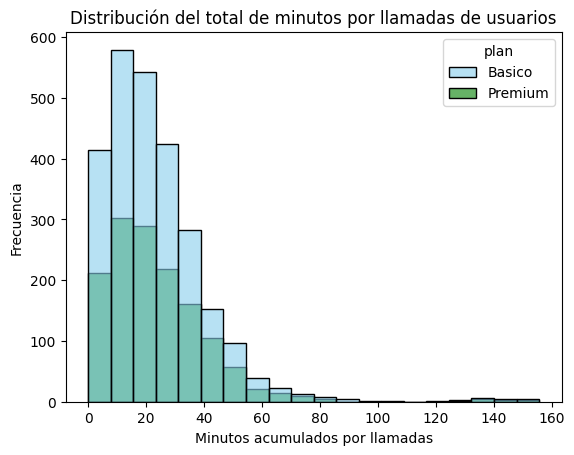

In [296]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',  
    palette=['skyblue', 'green'],
    bins=20,
    alpha=0.6)


plt.xlabel('Minutos acumulados por llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribución del total de minutos por llamadas de usuarios')
plt.show()


**💡Insights: Distribuación de cantidad de minutos por llamada**

La distribución presenta un sesgo positivo (hacia la derecha), en este histograma se ve mas marcado diferente a los que analizamos anteriormente, el pico está entre 10–20 minutos y la cola se extiende hasta los 160 minutos, lo que indica la existencia de llamadas extremadamente largas en una minoría de usuarios.

En este caso el plan básico, concentra la mayor frecuencia en 0–20 minutos con un pico ~580. A partir de los 40 minutos la caída es muy brusca, lo que indica que la mayoría de usuarios Básico hace llamadas cortas y en cuanto al plan premium, su pico también está en 10–20 minutos con alrededor de 300, pero proporcionalmente tiene mayor presencia relativa en franjas medias entre 20 y 40 minutos comparado con el plan básico, sugiriendo que los usuarios Premium tienden a llamadas algo más largas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- 
Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.


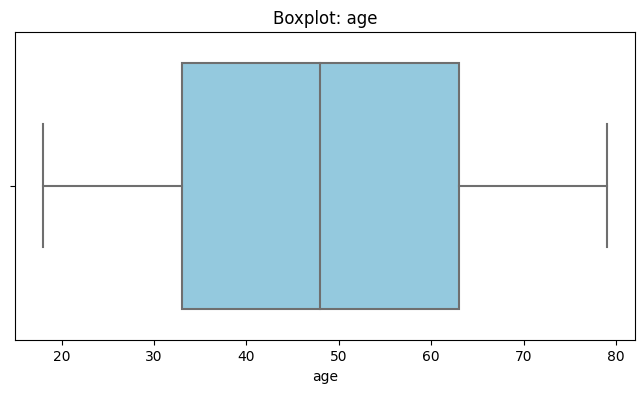

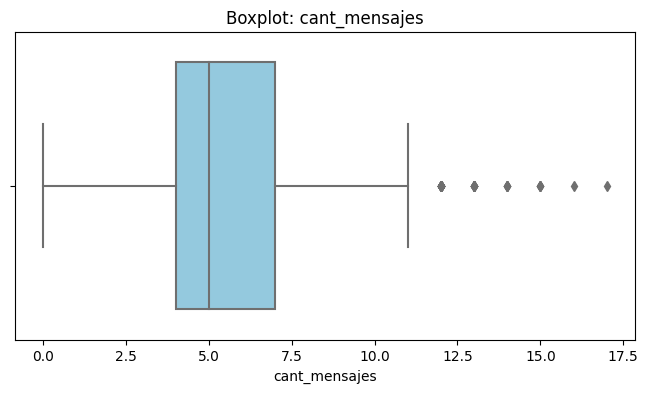

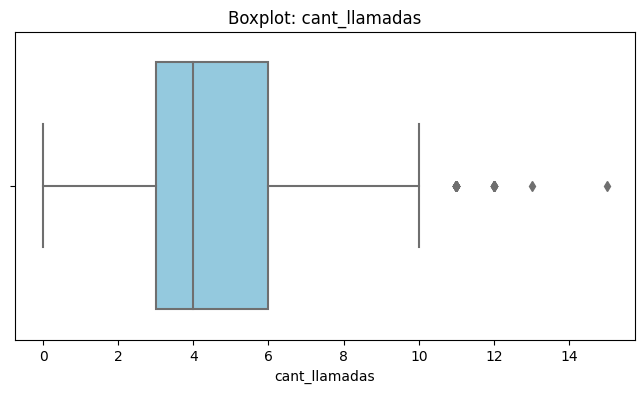

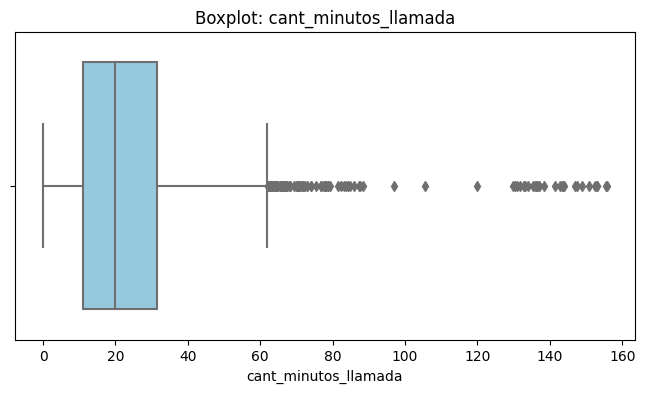

In [297]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, hue='plan', palette=['skyblue', 'green'])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: El boxplot no nos presenta ouliers ya que anteriormente se trabajo con estos valores y se les dio un tratamiento ya que habian valores -999.
- cant_mensajes: En este boxplot si se visualizan ouliers los cuales se pueden apreciar como puntos aislados, estos aparecen solo del lado derecho, después de Q3, por eso solo necesitamos calcular el límite superior.
- cant_llamadas: Los oulier aparecen despues del limite superior por lo que es el que tenemos que analizar al igual que el caso anterior.
- cant_minutos_llamada: Este es el caso más crítico de todos los anteriores ya que esta variable tiene la mayor cantidad de outliers del dataset, todos del lado derecho.


In [298]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"--- {col} ---")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite superior: {limite_superior}")
    print(f"Cantidad de outliers: {(user_profile[col] > limite_superior).sum()}")
    print()


--- cant_mensajes ---
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
Cantidad de outliers: 46

--- cant_llamadas ---
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
Cantidad de outliers: 30

--- cant_minutos_llamada ---
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
Cantidad de outliers: 109



In [299]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



###**💡Insights:**
**- cant_mensajes:** mantener o no outliers, porqué? En este caso lo mantendria porque los valores extremos (12–17 mensajes) representan usuarios de alto compromiso. Son comportamientos reales y válidos dentro de una plataforma de comunicación. Eliminarlos sesgaría el modelo hacia usuarios promedio e ignoraría a usuarios intensivos, que pueden ser clave para predecir una conversión a un plan Premium.

**- cant_llamadas:** mantener o no outliers, porqué? En este caso tambien los mantendria los outliers (11–15 llamadas) ya que estos corresponden a usuarios muy activos en voz. Al igual que mensajes, son datos legítimos que reflejan patrones de uso real. Dado que la cantidad de puntos es baja (pocos diamantes en el boxplot), su impacto en el modelo es mínimo si se conservan.

**- cant_minutos_llamada:** mantener o no outliers, porqué? En este caso en particular los mantendria pero con precaución
Es el caso más complejo. La nube densa de outliers (65–160 minutos) sugiere que no son errores, sino un segmento real de usuarios con llamadas muy largas. 


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [300]:
# Crear columna grupo_uso


def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)




In [301]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [302]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)



In [303]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

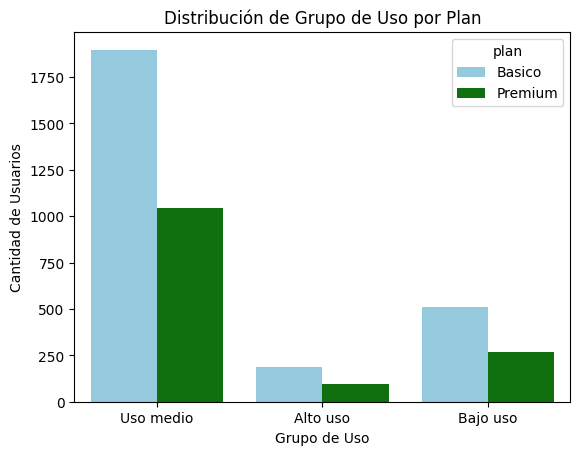

In [304]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Grupo de Uso por Plan')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()




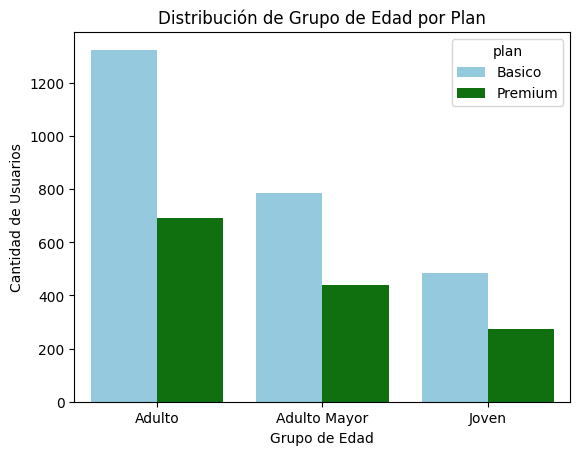

In [305]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Grupo de Edad por Plan')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? Lo primero que realice fue importar (import pandas as pd, import seaborn as sns,import matplotlib.pyplot as plt) luego cargue los 3 Dataset y de cada uno que me mostrara las cinco primeras columnas con el metodo .head()

para la exploracion de mis dataframe use .shape que muestra el número de filas y columnas de cada dataset, seguido a esto use .info() en cada DataFrame para obtener un resumen completo de columnas, tipos de datos y valores no nulos.

con estos metodos podemos visualizar de que tipo son los datos y si encontramos algun valor nulo.

El siguiente paso en mi analisis es la identificación de problemas de calidad de datos, para ello, se hizo una revision de valores nulos con el objetivo de detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

lo que se realizo fue:

Contar valores nulos por columna para cada dataset.

Calcular la proporción de nulos por columna para cada dataset.

Despues de aplicar el metodo para detectar los Nulos se puede observar en el Dataset de user que: City tiene un 11,7% de valores nulos por lo que entraria en el Hint en los que generalmente se investigan para imputarlo o dejarlos como nulos.

churn_date tiene un 88,35% de valores nulos, segun el hint estos valores normalmente se ignoran o se eliminan, en este caso nos representa la fecha de cancelación, por lo que solamente se registra la fecha donde se dio de baja el servicio por lo que en este caso los dejaria como nulos ya que considero que es una informacion valioso.

Por otro lado en el Dataset Usage verifique que: date tiene el 0,125 de nulos por lo que este caso suele ser simple de imputacion o dejarlos directamente como nulos. duration tiene un 55,19% de valores nulos lo cual no encaja en los rangos de hint, este sucede por son llamdas las cuales no tienen longitud de texto, asi mismo nos paso con length tiene un 44,74% de valores nulos al igual que el caso anterior no encaja en los rangos de hint, por lo que los textos no tienen duracion de minutos, por lo que estos dos paramentros no los eliminaria los dejare como nulos.

En cuanto al dataset plans solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no se necesita exploración adicional.


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
  **Por grupo de edad** en un principio age nos mostraba que el valor mínimo es −999, por lo que se puedo concluir que no es una edad real. Esto infla la desviación típica hasta 123, que de otro modo sería ~15–16 para edades reales, pero cuando realizamos la visualizacion por medio del histograma  de age, la distribución era simétrica sin outliers.
  En este punto segmentamos segun la edad joven, adulto, adulto mayor
**Por grupo de uso** usamos una segmentacion de bajo uso entran los de  5 , que son aquellos usuarios pasivos, uso medio mayor de 10 son considerados como usuarios regulares y los de uso alto los demas.
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

En la segmentacion de l analisis podemos destacar 3 muy valiosos para la empresa.

En primer lugar estan los jóvenes + Alto Uso + Plan Básico: este segmento se puede considerar como uno de los  más valioso y con mayor potencial, ya demuestran alto compromiso con la plataforma pero aún no migraron a Premium, solo faltaria ofrecerles un buen incentivo, para que se pudan cambiar al plan premium.

En segundo lugar tenemos el grupo de adultos (30–59) + Uso Medio, estos tienen una base estable y mayoritaria del negocio. No generan el mayor ingreso individual, pero su volumen los hace críticos para la salud financiera de ConnectaTel. Perder este segmento sería el mayor riesgo para la empresa.

Y por ultimo tenemos el segmento de los adultos Mayores + Alto uso de llamadas, por lo generalmente las empresas este segmento es frecuentemente ignorado pero que muestra alta dependencia del servicio de voz. Su fidelidad suele ser mayor que la de usuarios jóvenes, lo que los convierte en clientes de alto valor a largo plazo.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

En este analisis podemos concluir que los outliers NO son ruido pueden ser mas bien oportunidades.
Los usuarios con uso extremo en mensajes, llamadas y minutos son exactamente el perfil que ConnectaTel debería priorizar para retención y conversión a Premium, ya que su alto nivel de uso indica una dependencia real del servicio que puede monetizarse con el plan adecuado.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

  Podriamos rediseñar los planes actuales ya que esta cuenta con solo dos, por un lado el basico y por el otro el premium, seria bueno implementar otros dos con el fin de captar mas usuarios, se podria plantear que ademas de los dos que se tienen agregar otros dos por ejemplo uno que se llame **conecta joven* que estos usan mayor el servicio del text y el otro conecta pro donde podamos incluir los adultos con mas servicios de llamada.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

En el analisis se dectectaron valores nulos, por un lado tenemiamos las columnas numericas y por otro lado las columnas categoricas, en cuanto a las numericas tenemos La columna age la cual nos muestro que el valor mínimo era −999, por lo que se puedo concluir que no es una edad real. Esto infla la desviación típica hasta 123, y de otro modo sería ~15–16 para edades reales. 
En cuanto a las columnas categoricas esta la columna city es la de mayor riesgo dado que ya tiene 469 nulos reales, es probable que esconda valores inválidos.

En el caso de la columna age los datos - 999 se deberian tratar como nulos, por otro lado en el caso de la columna City tome la decisión de remplazarlos con NaN, con el fin de decidir si despues los mantenemos o los eliminariamos.

Tambien se tiene que tener en cuenta que en el año 2026 presenta 40 registros sospechosos, por lo que se puede deducir que son fechas futuras imposibles que representan el 1% del total y deben tratarse como datos inválidos.


🔍 **Segmentos por Edad**
El grupo Adulto (30–59 años) es el más numeroso y representa la base estable del negocio, con un uso equilibrado entre llamadas y mensajes y el grupo de
los Jóvenes (< 30 años) muestran mayor afinidad con mensajes, mientras que los Adultos Mayores (≥ 60 años) tienen mayor dependencia de llamadas de voz.


📊 **Segmentos por Nivel de Uso**
El segmento de Alto Uso concentra los outliers detectados y representa a los usuarios con mayor comportamiento de la plataforma.
El segmento de Bajo Uso es el de mayor riesgo, ya que su baja interacción con el servicio indica poca dependencia del mismo.

➡️ Esto sugiere que ConnectaTel tiene una base de usuarios diversos y polarizada, por un lado un grupo pequeño de con uso extremo de la plataforma, y por el otro lado, un grupo amplio de usuarios pasivos, con el plan Básico dominando en todos los segmentos, lo que evidencia una oportunidad de conversión a Premium aún no explotada


💡 **Recomendaciones**
Crear un plan intermedio orientado a jóvenes con mensajes ilimitados y precio entre Básico y Premium, para capturar el segmento de alto uso de mensajes sin requerir el salto directo a Premium.
Implementar un plan exclusivo de minutos extendidos para los usuarios con llamadas de 65–160 minutos, y una estrategia de reactivación para usuarios de Bajo Uso antes de que cancelen el servicio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`  https://github.com/blancayamilegarciacalvo-cloud/Sprint7-final-project--Analisis_Connecta-Tel/tree/main